# Questão da Função

"""
Aproximação de função com MLP usando scikit-learn (MLPRegressor).

Função alvo:
    f(x) = 10x^5 + 5x^4 + 2x^3 - 0.5x^2 + 3x + 2,   0 <= x <= 5

Etapas:
  1. Geração dos conjuntos de treino e teste
  2. Normalização (StandardScaler) — necessária pois f(x) varia de ~2 até ~34.630
  3. Definição e treinamento do MLPRegressor
  4. Acompanhamento do erro de treino e validação (usando early_stopping=False e
     validation via callback manual, já que o MLPRegressor do sklearn não expõe
     erro de teste por época nativamente — contornamos treinando em blocos de
     épocas com warm_start=True)
  5. Geração dos gráficos e métricas solicitadas
"""

In [75]:
import copy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)

In [76]:
def f(x):
    return 10 * x**5 + 5 * x**4 + 2 * x**3 - 0.5 * x**2 + 3 * x + 2

N_AMOSTRAS = 400
X_TODOS = np.random.uniform(0, 5, N_AMOSTRAS)
Y_TODOS = f(X_TODOS)

# Split em 3 partes: 60% treino / 20% validação / 20% teste
X_tmp, X_teste, y_tmp, y_teste = train_test_split(X_TODOS, Y_TODOS, test_size=0.2, random_state=42)
X_treino, X_val, y_treino, y_val = train_test_split(X_tmp, y_tmp, test_size=0.25, random_state=42)

X_treino = X_treino.reshape(-1, 1)
X_val = X_val.reshape(-1, 1)
X_teste = X_teste.reshape(-1, 1)

print(f"Treino: {len(X_treino)} | Validação: {len(X_val)} | Teste: {len(X_teste)}")

Treino: 240 | Validação: 80 | Teste: 80


f(x) varia de 2 até 34630, portanto é preciso normalizar para que eles estejam em uma escala menor.

In [77]:
# Normalização (fit SÓ no treino)
scaler_x = StandardScaler().fit(X_treino)
scaler_y = StandardScaler().fit(y_treino.reshape(-1, 1))

Xn_treino = scaler_x.transform(X_treino)
Xn_teste = scaler_x.transform(X_teste)
Xn_val = scaler_x.transform(X_val)
yn_treino = scaler_y.transform(y_treino.reshape(-1, 1)).ravel()
yn_teste = scaler_y.transform(y_teste.reshape(-1, 1)).ravel()
yn_val = scaler_y.transform(y_val.reshape(-1, 1)).ravel()

Arquitetura implementada com três camadas ocultas, com 64, 64 e 32 neurônios, ativação Relu e otimizador Adam, alem do learning rate adaptive para reduziro o passo quando o treino estagnar.

In [19]:
rede = MLPRegressor(
    hidden_layer_sizes=(64, 64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.01,
    learning_rate="adaptive",
    random_state=42,
)

EPOCAS = 1000
hist_erro_treino, hist_erro_val = [], []
melhor_erro_val = np.inf
melhor_rede = None

for epoca in range(EPOCAS):
    rede.partial_fit(Xn_treino, yn_treino)

    pred_treino = rede.predict(Xn_treino)
    pred_val = rede.predict(Xn_val)

    erro_treino = mean_squared_error(yn_treino, pred_treino)
    erro_val = mean_squared_error(yn_val, pred_val)

    hist_erro_treino.append(erro_treino)
    hist_erro_val.append(erro_val)

    # Checkpoint escolhido pela VALIDAÇÃO (o teste nunca entra aqui)
    if erro_val < melhor_erro_val:
        melhor_erro_val = erro_val
        melhor_rede = copy.deepcopy(rede)

    if epoca % 100 == 0 or epoca == EPOCAS - 1:
        print(f"Época {epoca:5d} | MSE treino: {erro_treino:.6f} | MSE val: {erro_val:.6f}")

rede = melhor_rede
print(f"\nMelhor MSE de Validação (normalizado): {melhor_erro_val:.6f}")

Época     0 | MSE treino: 0.430498 | MSE val: 0.303504
Época   100 | MSE treino: 0.000047 | MSE val: 0.000064
Época   200 | MSE treino: 0.000035 | MSE val: 0.000055
Época   300 | MSE treino: 0.000065 | MSE val: 0.000115
Época   400 | MSE treino: 0.000017 | MSE val: 0.000030
Época   500 | MSE treino: 0.000021 | MSE val: 0.000032
Época   600 | MSE treino: 0.002873 | MSE val: 0.002320
Época   700 | MSE treino: 0.002603 | MSE val: 0.002125
Época   800 | MSE treino: 0.002216 | MSE val: 0.001710
Época   900 | MSE treino: 0.000081 | MSE val: 0.000067
Época   999 | MSE treino: 0.000278 | MSE val: 0.000248

Melhor MSE de Validação (normalizado): 0.000021


O modelo escolhido para avaliação do conjunto de teste foi o melhor modelo da validação.

In [20]:
pred_teste_norm = rede.predict(Xn_teste)
pred_teste = scaler_y.inverse_transform(pred_teste_norm.reshape(-1, 1)).ravel()

mae = mean_absolute_error(y_teste, pred_teste)
mse = mean_squared_error(y_teste, pred_teste)
rmse = np.sqrt(mse)

print("===== Métricas no conjunto de TESTE (escala original) =====")
print(f"MAE  : {mae:,.4f}")
print(f"MSE  : {mse:,.4f}")
print(f"RMSE : {rmse:,.4f}")

===== Métricas no conjunto de TESTE (escala original) =====
MAE  : 24.1931
MSE  : 1,505.1807
RMSE : 38.7967


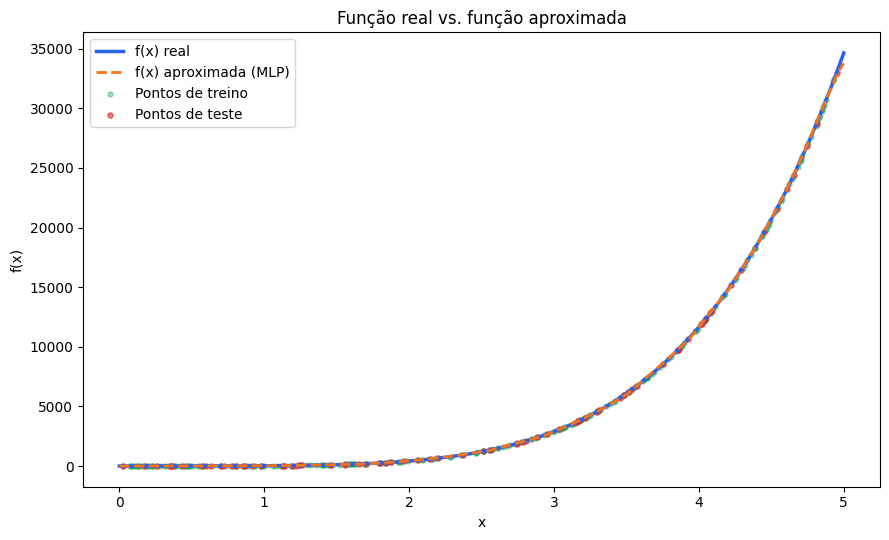

In [21]:
# Funçao real x aproximada

x_denso = np.linspace(0, 5, 500)
y_denso_real = f(x_denso)
x_denso_norm = scaler_x.transform(x_denso.reshape(-1, 1))
y_denso_pred = scaler_y.inverse_transform(rede.predict(x_denso_norm).reshape(-1, 1)).ravel()

plt.figure(figsize=(9, 5.5))
plt.plot(x_denso, y_denso_real, label="f(x) real", color="#2563eb", linewidth=2.5)
plt.plot(x_denso, y_denso_pred, label="f(x) aproximada (MLP)", color="#f97316", linewidth=2, linestyle="--")
plt.scatter(X_treino, y_treino, s=12, color="#16a34a", alpha=0.4, label="Pontos de treino")
plt.scatter(X_teste, y_teste, s=14, color="#dc2626", alpha=0.6, label="Pontos de teste")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Função real vs. função aproximada")
plt.legend()
plt.tight_layout()
plt.show()

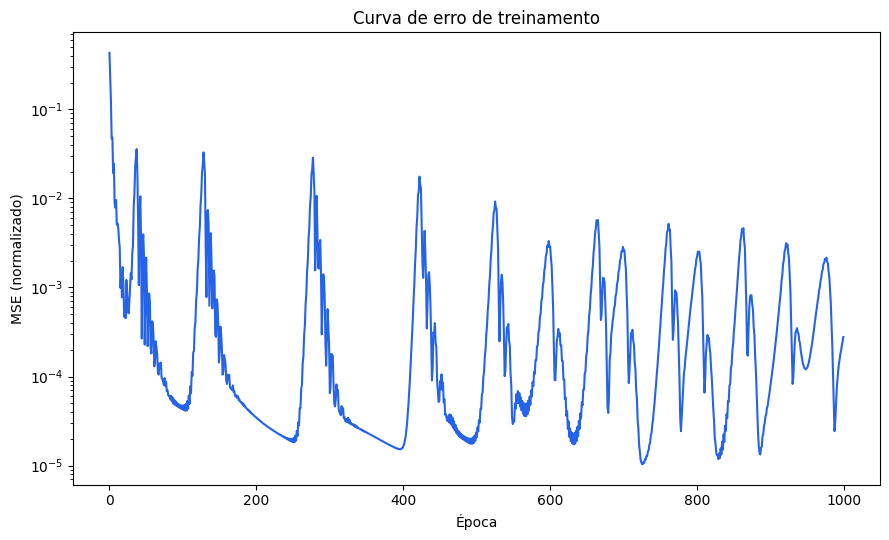

In [22]:
#  Curvas de erro (treino e validação/teste) ---

plt.figure(figsize=(9, 5.5))
plt.plot(hist_erro_treino, color="#2563eb")
plt.xlabel("Época")
plt.ylabel("MSE (normalizado)")
plt.yscale("log")
plt.title("Curva de erro de treinamento")
plt.tight_layout()
plt.show()

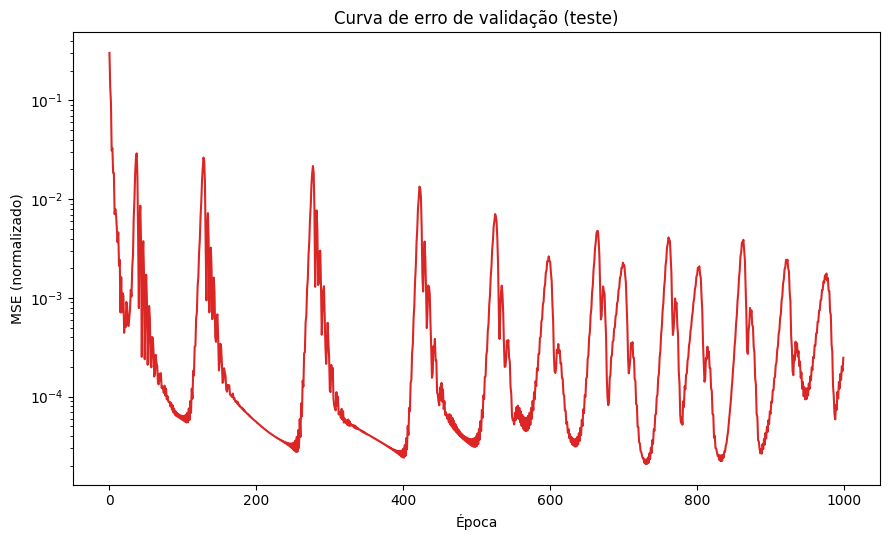

In [23]:
# Curva de erro de validação (teste)

plt.figure(figsize=(9, 5.5))
plt.plot(hist_erro_val, color="#dc2626")
plt.xlabel("Época")
plt.ylabel("MSE (normalizado)")
plt.yscale("log")
plt.title("Curva de erro de validação (teste)")
plt.tight_layout()
plt.show()

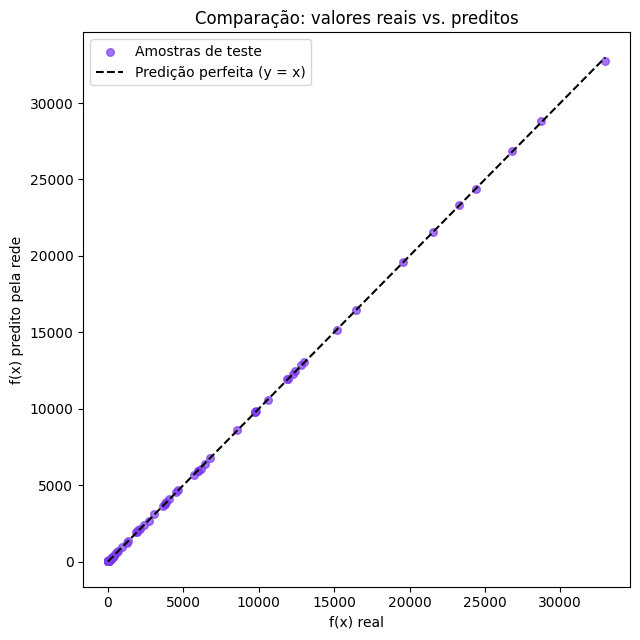

In [24]:
plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_teste, pred_teste, color="#7c3aed", alpha=0.7, s=30, label="Amostras de teste")
lim_min, lim_max = min(y_teste.min(), pred_teste.min()), max(y_teste.max(), pred_teste.max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], color="black", linestyle="--", linewidth=1.5, label="Predição perfeita (y = x)")
plt.xlabel("f(x) real")
plt.ylabel("f(x) predito pela rede")
plt.title("Comparação: valores reais vs. preditos")
plt.legend()
plt.tight_layout()
plt.show()

# Questão 1b)

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
from sklearn.datasets import fetch_california_housing
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)

In [26]:
dados = fetch_california_housing(as_frame=True)
df_california = dados.frame

In [27]:
df_california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [28]:
df_california.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Análise de Nulos

In [29]:
df_null = df_california.isna().sum()
sum(df_null)

0

Matriz de Correlação entre os atributos

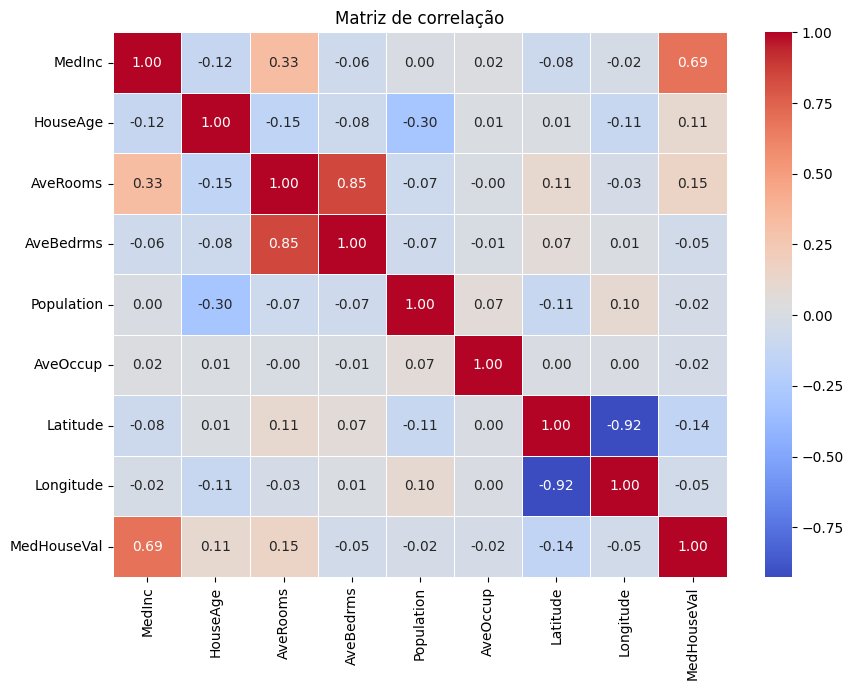

In [30]:
plt.figure(figsize=(9, 7))
corr = df_california.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlação")
plt.tight_layout()
plt.show()

Divisão em Treino e Teste

In [31]:
X = df_california.drop(columns="MedHouseVal").values
y = df_california["MedHouseVal"].values

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treino: {len(X_treino)} | Teste: {len(X_teste)}")

Treino: 16512 | Teste: 4128


Normalização

In [32]:
scaler_x = StandardScaler().fit(X_treino)
scaler_y = StandardScaler().fit(y_treino.reshape(-1, 1))

Xn_treino = scaler_x.transform(X_treino)
Xn_teste = scaler_x.transform(X_teste)
yn_treino = scaler_y.transform(y_treino.reshape(-1, 1)).ravel()

In [33]:
# early_stopping=True faz o MLPRegressor reservar sozinho uma fatia do
# TREINO (validation_fraction) como validação interna — sem precisar
# tocar no conjunto de teste em nenhum momento do treinamento.
# Ele também já guarda automaticamente os pesos da melhor época de validação.
rede = MLPRegressor(
    hidden_layer_sizes=(64, 64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.01,
    learning_rate="adaptive",
    early_stopping=True,
    validation_fraction=0.2,   # 20% do TREINO vira validação interna
    n_iter_no_change=15,
    max_iter=1000,
    random_state=42,
)

rede.fit(Xn_treino, yn_treino)

print(f"Treino parou na época: {rede.n_iter_}")
print(f"Melhor score de validação (R²): {rede.best_validation_score_:.4f}")

Treino parou na época: 61
Melhor score de validação (R²): 0.7896


Gráfico da Curva de Erro

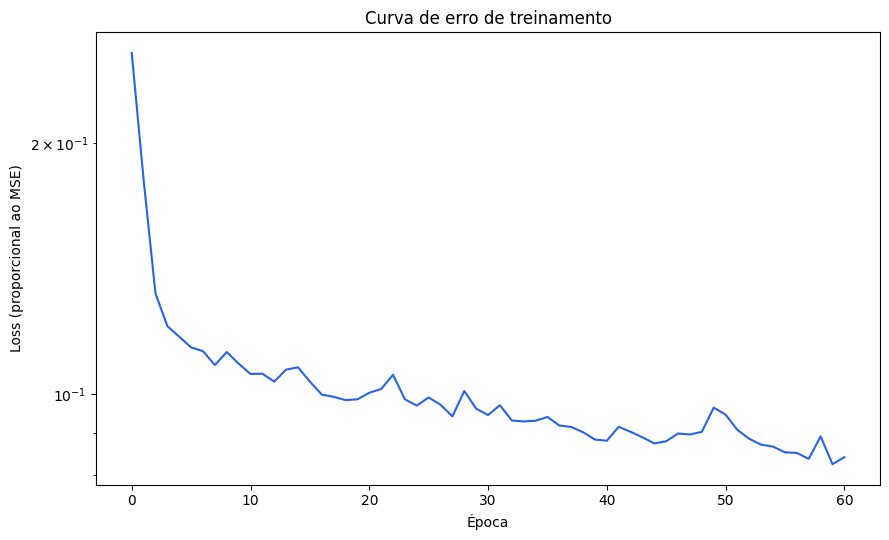

In [34]:
plt.figure(figsize=(9, 5.5))
plt.plot(rede.loss_curve_, color="#2563eb")
plt.xlabel("Época")
plt.ylabel("Loss (proporcional ao MSE)")
plt.yscale("log")
plt.title("Curva de erro de treinamento")
plt.tight_layout()
plt.show()

Curva de Validação

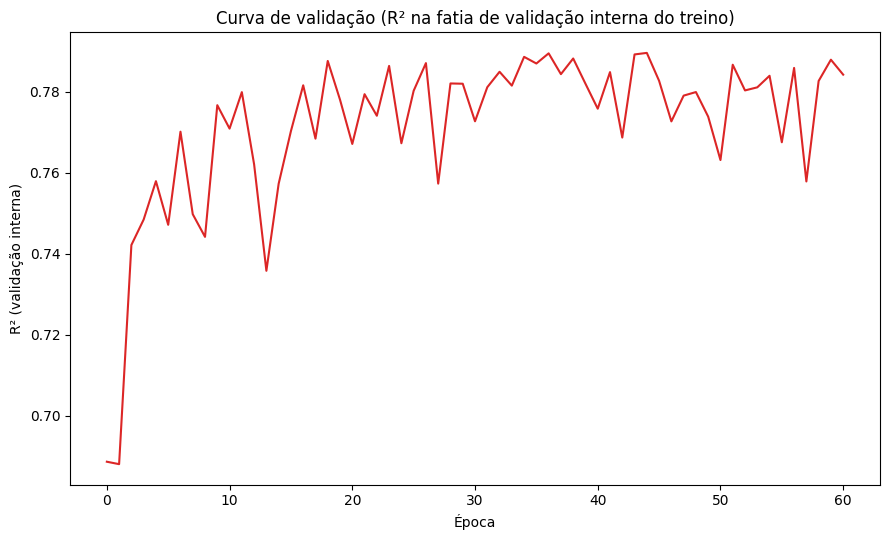

In [35]:
# O MLPRegressor expõe a validação interna como score R² por época
# (mais alto = melhor), não como erro — por isso o eixo aqui é diferente
# da curva de treinamento (que é loss, mais baixo = melhor).
plt.figure(figsize=(9, 5.5))
plt.plot(rede.validation_scores_, color="#dc2626")
plt.xlabel("Época")
plt.ylabel("R² (validação interna)")
plt.title("Curva de validação (R² na fatia de validação interna do treino)")
plt.tight_layout()
plt.show()

Métricas

In [36]:
pred_teste_norm = rede.predict(Xn_teste)
pred_teste = scaler_y.inverse_transform(pred_teste_norm.reshape(-1, 1)).ravel()

mae = mean_absolute_error(y_teste, pred_teste)
mse = mean_squared_error(y_teste, pred_teste)
rmse = np.sqrt(mse)

print("===== Métricas no conjunto de TESTE (escala original, US$ 100.000) =====")
print(f"MAE  : {mae:.4f}  (~US$ {mae*100000:,.0f})")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}  (~US$ {rmse*100000:,.0f})")

===== Métricas no conjunto de TESTE (escala original, US$ 100.000) =====
MAE  : 0.3615  (~US$ 36,145)
MSE  : 0.2723
RMSE : 0.5218  (~US$ 52,179)


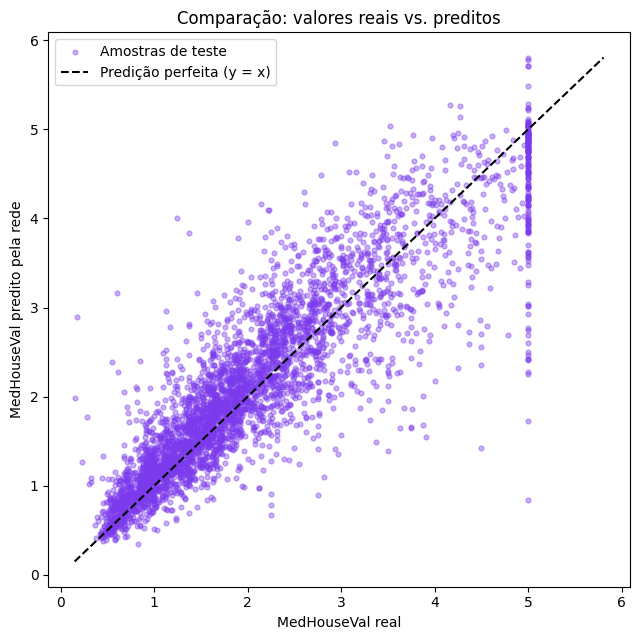

In [37]:
plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_teste, pred_teste, color="#7c3aed", alpha=0.4, s=12, label="Amostras de teste")
lim_min, lim_max = min(y_teste.min(), pred_teste.min()), max(y_teste.max(), pred_teste.max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], color="black", linestyle="--",
          linewidth=1.5, label="Predição perfeita (y = x)")
plt.xlabel("MedHouseVal real")
plt.ylabel("MedHouseVal predito pela rede")
plt.title("Comparação: valores reais vs. preditos")
plt.legend()
plt.tight_layout()
plt.show()

# Questão Titanic

In [38]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [39]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [40]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [41]:
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


# Tratamento dos Dados

In [42]:
df = pd.concat([train, test], ignore_index=True)

In [43]:
df[df['Fare'] == 7.2500]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
94,95,0.0,3,"Coxon, Mr. Daniel",male,59.0,0,0,364500,7.25,NaN,S
212,213,0.0,3,"Perkin, Mr. John Henry",male,22.0,0,0,A/5 21174,7.25,NaN,S
227,228,0.0,3,"Lovell, Mr. John Hall (""Henry"")",male,20.5,0,0,A/5 21173,7.25,NaN,S
250,251,0.0,3,"Reed, Mr. James George",male,NaN,0,0,362316,7.25,NaN,S
320,321,0.0,3,"Dennis, Mr. Samuel",male,22.0,0,0,A/5 21172,7.25,NaN,S
365,366,0.0,3,"Adahl, Mr. Mauritz Nils Martin",male,30.0,0,0,C 7076,7.25,NaN,S
376,377,1.0,3,"Landergren, Miss. Aurora Adelia",female,22.0,0,0,C 7077,7.25,NaN,S
425,426,0.0,3,"Wiseman, Mr. Phillippe",male,NaN,0,0,A/4. 34244,7.25,NaN,S
470,471,0.0,3,"Keefe, Mr. Arthur",male,NaN,0,0,323592,7.25,NaN,S


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


In [45]:
# O atributo 'Cabin' tem muitos valores nulos, então optei por remover a coluna, visto que não tem como inputar de algum jeito.
# O atributo 'Name', 'PassengerId' e 'Ticket 'não agregam em nada para a predição, pois nenhum deles pode ter influenciado na morte.


df = df.drop(columns=['Cabin', 'Name', 'PassengerId', 'Ticket'])

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    float64
 1   Pclass    1309 non-null   int64  
 2   Sex       1309 non-null   object 
 3   Age       1046 non-null   float64
 4   SibSp     1309 non-null   int64  
 5   Parch     1309 non-null   int64  
 6   Fare      1308 non-null   float64
 7   Embarked  1307 non-null   object 
dtypes: float64(3), int64(3), object(2)
memory usage: 81.9+ KB


Análise de valores nulos

In [47]:
df_null = df.isna().sum()
sum(df_null)

684

Análise de Duplicatas

In [48]:
dup = df.duplicated()
sum(dup)

149

In [49]:
df = df.drop_duplicates()

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1160 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  780 non-null    float64
 1   Pclass    1160 non-null   int64  
 2   Sex       1160 non-null   object 
 3   Age       998 non-null    float64
 4   SibSp     1160 non-null   int64  
 5   Parch     1160 non-null   int64  
 6   Fare      1159 non-null   float64
 7   Embarked  1158 non-null   object 
dtypes: float64(3), int64(3), object(2)
memory usage: 81.6+ KB


Removendo valores da coluna Survived

In [51]:
# Visto que a coluna survived é nosso atributo alvo, não faz sentido ter valores nulos para o treinamento e muito menos inputar dado.

df = df.dropna(subset=['Survived'])

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 780 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  780 non-null    float64
 1   Pclass    780 non-null    int64  
 2   Sex       780 non-null    object 
 3   Age       676 non-null    float64
 4   SibSp     780 non-null    int64  
 5   Parch     780 non-null    int64  
 6   Fare      780 non-null    float64
 7   Embarked  778 non-null    object 
dtypes: float64(3), int64(3), object(2)
memory usage: 54.8+ KB


Analisando o balanceamento da classe alvo

In [53]:
df['Survived'].value_counts() # Balanceado

,count
Survived,
0.0,458
1.0,322


Caso houvesse um desbalanceamento mais considerável, poderia ser feito técnicas de balanceamento como Undersampling e Oversampling.

In [54]:
labelencoder_y = LabelEncoder()
df['Sex'] = labelencoder_y.fit_transform(df['Sex'])
df['Embarked'] = labelencoder_y.fit_transform(df['Embarked'])

LabelEncoding para transformar as colunas categóricas em numéricas.

In [55]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.0,3,1,22.0,1,0,7.2500,2
1,1.0,1,0,38.0,1,0,71.2833,0
2,1.0,3,0,26.0,0,0,7.9250,2
3,1.0,1,0,35.0,1,0,53.1000,2
4,0.0,3,1,35.0,0,0,8.0500,2
...,...,...,...,...,...,...,...,...
885,0.0,3,0,39.0,0,5,29.1250,1
887,1.0,1,0,19.0,0,0,30.0000,2
888,0.0,3,0,NaN,1,2,23.4500,2
889,1.0,1,1,26.0,0,0,30.0000,0


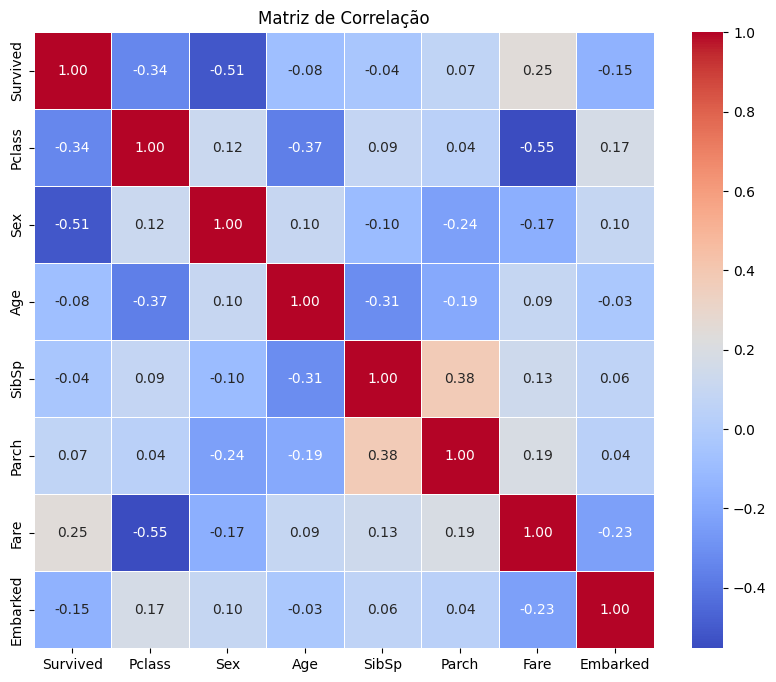

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcula a matriz de correlação
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação')
plt.show()

 A Pclass e a o sexo tem uma alta correlação com o atributo 'Survived'


In [57]:
df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,780.000000,780.000000,780.000000,676.000000,780.000000,780.000000,780.000000,780.000000
mean,0.412821,2.246154,0.625641,29.812751,0.525641,0.417949,34.829108,1.530769
std,0.492657,0.854452,0.484267,14.727098,0.988046,0.838536,52.263440,0.807746
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,20.000000,0.000000,0.000000,8.050000,1.000000
50%,0.000000,3.000000,1.000000,28.000000,0.000000,0.000000,15.950000,2.000000
75%,1.000000,3.000000,1.000000,39.000000,1.000000,1.000000,34.375000,2.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,3.000000


# Separando em Treino e Teste

In [58]:
x = df.drop(columns = 'Survived')
y = df['Survived']

In [59]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state=45, test_size=0.2)

In [60]:
xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 624 entries, 545 to 456
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    624 non-null    int64  
 1   Sex       624 non-null    int64  
 2   Age       538 non-null    float64
 3   SibSp     624 non-null    int64  
 4   Parch     624 non-null    int64  
 5   Fare      624 non-null    float64
 6   Embarked  624 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 39.0 KB


In [61]:
xtest.info()

<class 'pandas.core.frame.DataFrame'>
Index: 156 entries, 451 to 712
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    156 non-null    int64  
 1   Sex       156 non-null    int64  
 2   Age       138 non-null    float64
 3   SibSp     156 non-null    int64  
 4   Parch     156 non-null    int64  
 5   Fare      156 non-null    float64
 6   Embarked  156 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 9.8 KB


Ainda possuem valores nulos na coluna de idade. Optei por preencher esses valores com a média das idades APÓS a separação entre treino e teste para não haver vazamento de dados.

In [62]:
xtrain['Age'] = xtrain['Age'].fillna(xtrain['Age'].mean())
xtest['Age'] = xtest['Age'].fillna(xtest['Age'].mean())

In [63]:
xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 624 entries, 545 to 456
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    624 non-null    int64  
 1   Sex       624 non-null    int64  
 2   Age       624 non-null    float64
 3   SibSp     624 non-null    int64  
 4   Parch     624 non-null    int64  
 5   Fare      624 non-null    float64
 6   Embarked  624 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 39.0 KB


In [64]:
xtest.info()

<class 'pandas.core.frame.DataFrame'>
Index: 156 entries, 451 to 712
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    156 non-null    int64  
 1   Sex       156 non-null    int64  
 2   Age       156 non-null    float64
 3   SibSp     156 non-null    int64  
 4   Parch     156 non-null    int64  
 5   Fare      156 non-null    float64
 6   Embarked  156 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 9.8 KB


Os atributos do dataset possuem escalas muito diferentes, portanto é preciso normalizar os dados para uma mesma escala.

In [65]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
xtrain[xtrain.columns] = scaler.fit_transform(xtrain[xtrain.columns])
xtest[xtest.columns] = scaler.transform(xtest[xtest.columns]) # Fit apenas no treinamento

In [66]:
xtrain

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
545,0.0,1.0,0.798944,0.000,0.000000,0.050749,0.666667
840,1.0,1.0,0.246042,0.000,0.000000,0.015469,0.666667
618,0.5,0.0,0.044986,0.250,0.166667,0.076123,0.666667
246,1.0,0.0,0.308872,0.000,0.000000,0.015176,0.666667
337,0.0,0.0,0.509927,0.000,0.000000,0.262527,0.000000
...,...,...,...,...,...,...,...
824,1.0,1.0,0.019854,0.500,0.166667,0.077465,0.666667
688,1.0,1.0,0.220910,0.000,0.000000,0.015216,0.666667
615,0.5,0.0,0.296306,0.125,0.333333,0.126872,0.666667
727,1.0,0.0,0.370212,0.000,0.000000,0.015103,0.333333


# Treinamento

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, precision_score,
                              recall_score, f1_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [68]:
# Garantindo que os conjuntos estejam em float que é o formato que o keras espera
xtrain = np.asarray(xtrain).astype('float32')
xtest  = np.asarray(xtest).astype('float32')
ytrain = np.asarray(ytrain).astype('float32')
ytest  = np.asarray(ytest).astype('float32')

Arquitetura

In [69]:
n_features = xtrain.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(32, activation='relu', name='oculta_1'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu', name='oculta_2'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid', name='saida')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801 (3.13 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    xtrain, ytrain,
    validation_split=0.2,   # separa 20% do TREINO para validação (não usa o teste)
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5772 - loss: 0.6688 - val_accuracy: 0.6240 - val_loss: 0.6556
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5892 - loss: 0.6453 - val_accuracy: 0.6240 - val_loss: 0.6204
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6052 - loss: 0.6266 - val_accuracy: 0.6560 - val_loss: 0.5976
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6172 - loss: 0.6191 - val_accuracy: 0.7040 - val_loss: 0.5802
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6393 - loss: 0.6101 - val_accuracy: 0.7200 - val_loss: 0.5692
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6613 - loss: 0.6125 - val_accuracy: 0.7200 - val_loss: 0.5636
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6934 - loss: 0.5962 - val_accuracy: 0.7200 - val_loss: 0.5541
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7174 - loss: 0.5834 - val_accuracy: 0.8000

Curva de Erro

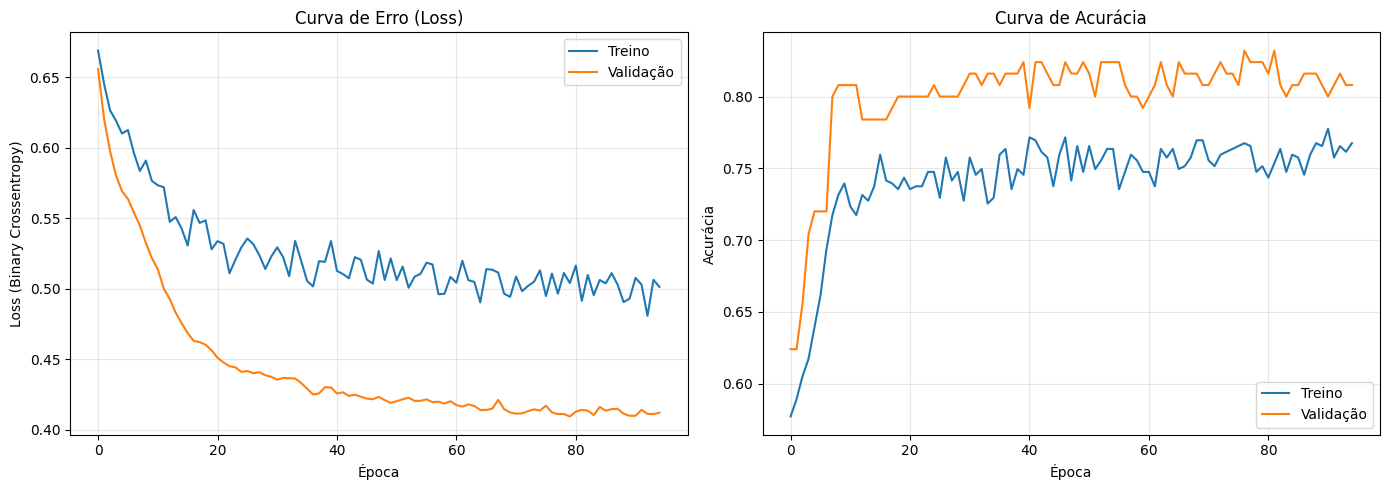

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Treino')
axes[0].plot(history.history['val_loss'], label='Validação')
axes[0].set_title('Curva de Erro (Loss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (Binary Crossentropy)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Treino')
axes[1].plot(history.history['val_accuracy'], label='Validação')
axes[1].set_title('Curva de Acurácia')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [72]:
y_pred_proba = model.predict(xtest)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 


Matriz de Confusão

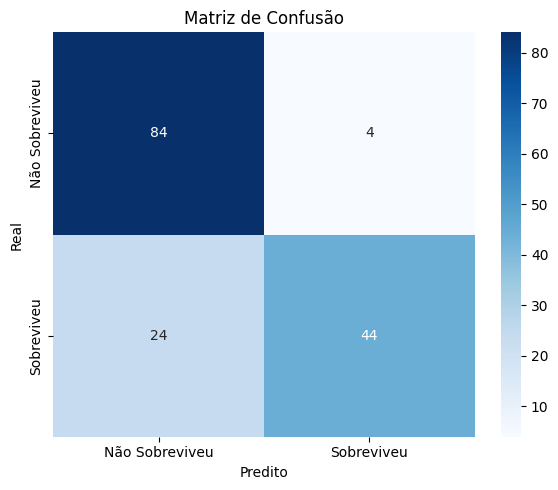

In [73]:
cm = confusion_matrix(ytest, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Sobreviveu', 'Sobreviveu'],
            yticklabels=['Não Sobreviveu', 'Sobreviveu'])
plt.title('Matriz de Confusão')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

Métricas

In [74]:
acc = accuracy_score(ytest, y_pred)
prec = precision_score(ytest, y_pred)
rec = recall_score(ytest, y_pred)
f1 = f1_score(ytest, y_pred)

print("\n===== MÉTRICAS NO CONJUNTO DE TESTE =====")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nRelatório completo:")
print(classification_report(ytest, y_pred,
                             target_names=['Não Sobreviveu', 'Sobreviveu']))


===== MÉTRICAS NO CONJUNTO DE TESTE =====
Accuracy:  0.8205
Precision: 0.9167
Recall:    0.6471
F1-score:  0.7586

Relatório completo:
                precision    recall  f1-score   support

Não Sobreviveu       0.78      0.95      0.86        88
    Sobreviveu       0.92      0.65      0.76        68

      accuracy                           0.82       156
     macro avg       0.85      0.80      0.81       156
  weighted avg       0.84      0.82      0.81       156

